# ShopGuard Fraud URL Detection — Model Training

**Goal**: Train an MLP classifier on 16 URL-based features to detect scam websites, then export to ONNX for backend inference.

**Inputs**: `url_features_extracted1.csv` (≈101k rows, 16 features + label)
**Outputs**:
- `fraud_model.onnx` — trained model
- `scaler.pkl` — input normalization
- `feature_columns.json` — feature order (CRITICAL: backend must use this exact order)
- `model_metadata.json` — training info, metrics, threshold

**Pipeline**: load → preprocess → split → scale → train (PyTorch MLP) → evaluate → export ONNX → sanity check

## 1. Environment Setup

In [12]:
# ONNX 관련 패키지 설치 (Colab에는 PyTorch, sklearn, pandas는 기본 설치되어 있음)
!pip install -q onnx onnxruntime
!pip install -q onnx onnxruntime onnxscript

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import json
import joblib

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

# 재현성을 위한 시드 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

PyTorch: 2.10.0+cpu
CUDA available: False
Device: cpu


## 2. Load Data

Colab에서 사용할 경우 Drive에 CSV를 올려두고 마운트하거나, 직접 업로드합니다.
로컬에서는 `CSV_PATH`만 수정하면 됩니다.

In [13]:
# Colab에서 Drive 사용 시 (필요한 경우만 주석 해제)
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/26S_CS350_Software_Engineering/url_features_extracted1.csv'

# 또는 직접 업로드한 경우
# CSV_PATH = 'url_features_extracted1.csv'

df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"\nClass distribution:\n{df['ClassLabel'].value_counts()}")
print(f"\nNull count: {df.isnull().sum().sum()}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (101219, 18)

Class distribution:
ClassLabel
0.0    63678
1.0    37540
Name: count, dtype: int64

Null count: 1


,URL,url_length,has_ip_address,dot_count,https_flag,url_entropy,token_count,subdomain_count,query_param_count,tld_length,path_length,has_hyphen_in_domain,number_of_digits,tld_popularity,suspicious_file_extension,domain_name_length,percentage_numeric_chars,ClassLabel
0,https://keraekken-loagginnusa.godaddysites.com/,47,0,2,1,4.250669,6,1,1,3,1,1,0,1,0,12,0.0,0.0
1,https://metamsk01lgiix.godaddysites.com/,40,0,2,1,4.196439,6,1,1,3,1,0,2,1,0,12,5.0,0.0
2,http://myglobaltech.in/,23,0,1,0,3.936180,5,0,1,2,1,0,0,0,0,12,0.0,0.0
3,http://djtool-for-spotify.com/,30,0,1,0,3.894740,5,0,1,3,1,1,0,1,0,18,0.0,0.0
4,https://scearmcoommunnlty.com/invent/freind/get,47,0,1,1,4.143127,7,0,1,3,18,0,0,1,0,17,0.0,0.0


## 3. Preprocessing

- `URL` 컬럼은 모델 입력에서 제외 (16 feature만 사용)
- null 행 1개 제거
- **feature 순서를 리스트로 고정** — 백엔드 추론 시 반드시 동일한 순서로 입력해야 함

In [14]:
# null 제거
df = df.dropna().reset_index(drop=True)

# feature 컬럼 순서 정의 (이 순서가 백엔드와 일치해야 함)
FEATURE_COLUMNS = [
    'url_length', 'has_ip_address', 'dot_count', 'https_flag',
    'url_entropy', 'token_count', 'subdomain_count', 'query_param_count',
    'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits',
    'tld_popularity', 'suspicious_file_extension', 'domain_name_length',
    'percentage_numeric_chars'
]
TARGET_COLUMN = 'ClassLabel'

X = df[FEATURE_COLUMNS].astype(np.float32).values
y = df[TARGET_COLUMN].astype(np.float32).values

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Feature count: {len(FEATURE_COLUMNS)}")
print(f"Positive ratio (scam): {y.mean():.4f}")

X shape: (101218, 16), y shape: (101218,)
Feature count: 16
Positive ratio (scam): 0.3709


## 4. Train/Val/Test Split

70/15/15, stratified로 클래스 비율 유지.

In [15]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED  # 0.15/0.85 ≈ 0.1765
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Train pos ratio: {y_train.mean():.4f}")
print(f"Val pos ratio: {y_val.mean():.4f}")
print(f"Test pos ratio: {y_test.mean():.4f}")

Train: (70849, 16), Val: (15186, 16), Test: (15183, 16)
Train pos ratio: 0.3709
Val pos ratio: 0.3709
Test pos ratio: 0.3709


## 5. Feature Scaling

`StandardScaler`로 정규화. **scaler 객체를 반드시 저장** — 백엔드에서 동일한 scaler로 입력을 변환해야 모델이 정상 동작합니다.

Feature들의 스케일이 매우 다양함 (예: `url_length` 7~474 vs `https_flag` 0~1)이라 정규화 필수.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Scaler mean (first 5):", scaler.mean_[:5])
print("Scaler std (first 5):", scaler.scale_[:5])

Scaler mean (first 5): [35.03662719  0.48562436  3.00769242  0.40542562  3.97529882]
Scaler std (first 5): [16.82529645  0.4997933   0.93929875  0.49097422  0.30696903]


## 6. Model Definition

간단한 MLP: `16 → 64 → 32 → 1`. Dropout 0.3으로 과적합 방지.
출력은 logit (sigmoid는 BCEWithLogitsLoss 안에 포함).

In [17]:
class FraudMLP(nn.Module):
    def __init__(self, in_dim=16, hidden1=64, hidden2=32, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, 1)  # logit
        )

    def forward(self, x):
        return self.net(x)

model = FraudMLP(in_dim=len(FEATURE_COLUMNS)).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal params: {total_params}")

FraudMLP(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total params: 3201


## 7. Training Loop

- Loss: `BCEWithLogitsLoss` + `pos_weight` (클래스 불균형 보정)
- Optimizer: Adam, lr=1e-3
- Batch size: 256, Epochs: 30
- Early stopping: val loss가 5 epoch 동안 개선 없으면 중단

In [18]:
from torch.utils.data import DataLoader, TensorDataset

# Tensor 변환
X_train_t = torch.from_numpy(X_train_scaled)
y_train_t = torch.from_numpy(y_train).unsqueeze(1)
X_val_t = torch.from_numpy(X_val_scaled).to(device)
y_val_t = torch.from_numpy(y_val).unsqueeze(1).to(device)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=256, shuffle=True
)

# 클래스 불균형 보정: pos_weight = neg_count / pos_count
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = torch.tensor([neg_count / pos_count], device=device)
print(f"pos_weight: {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 30
PATIENCE = 5
best_val_loss = float('inf')
patience_counter = 0
best_state = None

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_loader.dataset)

    # Validate
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_preds = (torch.sigmoid(val_logits) > 0.5).float()
        val_acc = (val_preds == y_val_t).float().mean().item()

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

# Best 모델 복원
model.load_state_dict(best_state)
model.eval()
print(f"\nBest val_loss: {best_val_loss:.4f}")

pos_weight: 1.6962
Epoch 01 | train_loss=0.1466 | val_loss=0.0222 | val_acc=0.9937
Epoch 02 | train_loss=0.0239 | val_loss=0.0142 | val_acc=0.9957
Epoch 03 | train_loss=0.0167 | val_loss=0.0103 | val_acc=0.9972
Epoch 04 | train_loss=0.0127 | val_loss=0.0082 | val_acc=0.9975
Epoch 05 | train_loss=0.0101 | val_loss=0.0073 | val_acc=0.9982
Epoch 06 | train_loss=0.0085 | val_loss=0.0070 | val_acc=0.9981
Epoch 07 | train_loss=0.0080 | val_loss=0.0064 | val_acc=0.9986
Epoch 08 | train_loss=0.0076 | val_loss=0.0066 | val_acc=0.9982
Epoch 09 | train_loss=0.0069 | val_loss=0.0059 | val_acc=0.9986
Epoch 10 | train_loss=0.0065 | val_loss=0.0061 | val_acc=0.9985
Epoch 11 | train_loss=0.0065 | val_loss=0.0059 | val_acc=0.9989
Epoch 12 | train_loss=0.0061 | val_loss=0.0062 | val_acc=0.9985
Epoch 13 | train_loss=0.0059 | val_loss=0.0059 | val_acc=0.9987
Epoch 14 | train_loss=0.0056 | val_loss=0.0055 | val_acc=0.9989
Epoch 15 | train_loss=0.0057 | val_loss=0.0056 | val_acc=0.9986
Epoch 16 | train_loss

## 8. Evaluation

Test set에서 accuracy / precision / recall / F1 / ROC-AUC 측정.
사기 탐지에서는 **recall**이 중요 (진짜 사기를 놓치는 비용이 큼).
Threshold는 0.5로 시작하되, PR curve로 조정 가능.

In [19]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

X_test_t = torch.from_numpy(X_test_scaled).to(device)

with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

THRESHOLD = 0.5
test_preds = (test_probs > THRESHOLD).astype(np.int32)
y_test_int = y_test.astype(np.int32)

print(f"Threshold: {THRESHOLD}")
print(f"Accuracy:  {accuracy_score(y_test_int, test_preds):.4f}")
print(f"Precision: {precision_score(y_test_int, test_preds):.4f}")
print(f"Recall:    {recall_score(y_test_int, test_preds):.4f}")
print(f"F1:        {f1_score(y_test_int, test_preds):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test_int, test_probs):.4f}")

print(f"\nConfusion matrix:\n{confusion_matrix(y_test_int, test_preds)}")
print(f"\nClassification report:\n{classification_report(y_test_int, test_preds, target_names=['phishing', 'legitimate'])}")

Threshold: 0.5
Accuracy:  0.9988
Precision: 0.9977
Recall:    0.9991
F1:        0.9984
ROC-AUC:   1.0000

Confusion matrix:
[[9539   13]
 [   5 5626]]

Classification report:
              precision    recall  f1-score   support

    phishing       1.00      1.00      1.00      9552
  legitimate       1.00      1.00      1.00      5631

    accuracy                           1.00     15183
   macro avg       1.00      1.00      1.00     15183
weighted avg       1.00      1.00      1.00     15183



Best F1 threshold: 0.6661 (F1=0.9988)


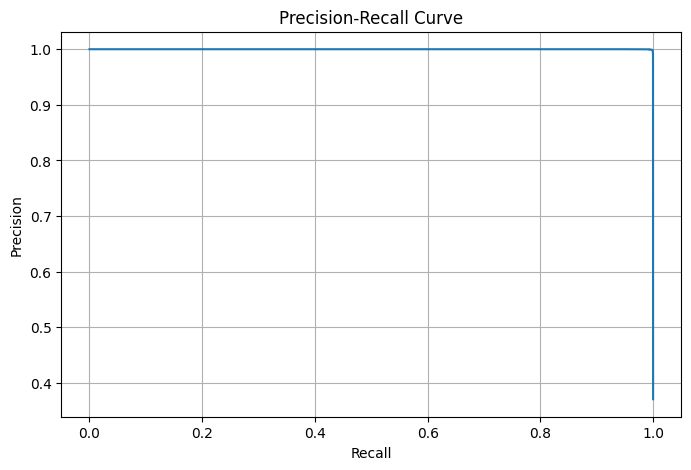

In [20]:
# (선택) PR curve로 threshold 튜닝
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test_int, test_probs)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])  # 마지막은 threshold가 없는 더미
best_threshold = thresholds[best_idx]
print(f"Best F1 threshold: {best_threshold:.4f} (F1={f1_scores[best_idx]:.4f})")

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

## 9. Export to ONNX

백엔드(`ai-worker`)에 넘길 4개 산출물 생성:
1. `fraud_model.onnx` — 모델 가중치
2. `scaler.pkl` — 정규화 파라미터
3. `feature_columns.json` — feature 순서
4. `model_metadata.json` — 학습 정보 및 임계값

In [21]:
import os
from datetime import datetime

OUTPUT_DIR = '/content/drive/MyDrive/26S_CS350_Software_Engineering/url_model_artifacts'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. ONNX export
model.eval()
model_cpu = model.to('cpu')
dummy_input = torch.randn(1, len(FEATURE_COLUMNS), dtype=torch.float32)

onnx_path = os.path.join(OUTPUT_DIR, 'fraud_model.onnx')
torch.onnx.export(
    model_cpu,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=['features'],
    output_names=['logit'],
    dynamic_axes={
        'features': {0: 'batch_size'},
        'logit': {0: 'batch_size'}
    }
)
print(f"✓ ONNX saved: {onnx_path}")

# 2. Scaler
scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved: {scaler_path}")

# 3. Feature columns
feature_path = os.path.join(OUTPUT_DIR, 'feature_columns.json')
with open(feature_path, 'w') as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)
print(f"✓ Feature columns saved: {feature_path}")

# 4. Metadata
metadata = {
    'trained_at': datetime.now().isoformat(),
    'framework': f'PyTorch {torch.__version__}',
    'model_arch': 'MLP (16 -> 64 -> 32 -> 1)',
    'n_features': len(FEATURE_COLUMNS),
    'n_train': int(len(X_train)),
    'n_val': int(len(X_val)),
    'n_test': int(len(X_test)),
    'threshold': float(THRESHOLD),
    'metrics': {
        'accuracy': float(accuracy_score(y_test_int, test_preds)),
        'precision': float(precision_score(y_test_int, test_preds)),
        'recall': float(recall_score(y_test_int, test_preds)),
        'f1': float(f1_score(y_test_int, test_preds)),
        'roc_auc': float(roc_auc_score(y_test_int, test_probs)),
    }
}
metadata_path = os.path.join(OUTPUT_DIR, 'model_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✓ Metadata saved: {metadata_path}")
print(f"\nMetadata:\n{json.dumps(metadata, indent=2)}")

/tmp/ipykernel_950/790927572.py:13: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0506 15:18:50.621000 950 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `FraudMLP([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FraudMLP([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
✓ ONNX saved: /content/drive/MyDrive/26S_CS350_Software_Engineering/url_model_artifacts/fraud_model.onnx
✓ Scaler saved: /content/drive/MyDrive/26S_CS350_Software_Engineering/url_model_artifacts/scaler.pkl
✓ Feature columns saved: /content/drive/MyDrive/26S_CS350_Software_Engineering/url_model_artifacts/feature_columns.json
✓ Metadata saved: /content/drive/MyDrive/26S_CS350_Software_Engineering/url_model_artifacts/model_metadata.json

Metadata:
{
  "trained_at": "2026-05-06T15:18:51.914441",
  "framework": "PyTorch 2.10.0+cpu",
  "model_arch": "MLP (16 -> 64 -> 32 -> 1)",
  "n_features": 16,
  "n_train": 70849,
  "n_val": 15186,
  "n_test": 15183,
  "threshold": 0.5,
  "metrics": {
    "accuracy": 0.998814463544754,
    "precision": 0.9976946267068629,
    "recall": 0.9991120582489789,
    "f1": 0.9984028393966282,
    "roc_auc": 0.9999882686087752
  }
}


## 10. Sanity Check

ONNX 모델을 다시 로드해서 PyTorch 추론 결과와 일치하는지 확인.
**이 셀이 통과해야 백엔드에 안전하게 가져갈 수 있습니다.**

In [22]:
import onnxruntime as ort

# ONNX 세션 생성
ort_session = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])

# 동일한 입력으로 PyTorch와 ONNX 출력 비교
sample_idx = np.random.choice(len(X_test_scaled), 10, replace=False)
sample_x = X_test_scaled[sample_idx]

# PyTorch
with torch.no_grad():
    torch_logits = model_cpu(torch.from_numpy(sample_x)).numpy()

# ONNX
ort_inputs = {'features': sample_x}
ort_logits = ort_session.run(None, ort_inputs)[0]

print("PyTorch logits:", torch_logits.flatten())
print("ONNX logits:   ", ort_logits.flatten())
print(f"\nMax abs diff: {np.abs(torch_logits - ort_logits).max():.2e}")

assert np.allclose(torch_logits, ort_logits, atol=1e-5), "ONNX와 PyTorch 결과 불일치"
print("\n✓ Sanity check passed. 백엔드에 안전하게 가져갈 수 있습니다.")

PyTorch logits: [ 20.088707  18.37974  -39.26454  -37.04745  -37.59978   18.404093
 -36.89381  -31.296314 -35.511345 -34.762836]
ONNX logits:    [ 20.088705  18.379742 -39.26454  -37.04745  -37.599777  18.404095
 -36.89381  -31.296314 -35.511345 -34.76284 ]

Max abs diff: 3.81e-06

✓ Sanity check passed. 백엔드에 안전하게 가져갈 수 있습니다.


## 11. Backend 통합 가이드

`model_artifacts/` 폴더 전체를 `ai-worker/worker/scoring/` 아래에 복사하세요.

**백엔드 추론 코드 예시** (`ai-worker/worker/scoring/risk_scorer.py`):
```python
import onnxruntime as ort
import joblib
import json
import numpy as np

class FraudScorer:
    def __init__(self, artifacts_dir='./model_artifacts'):
        self.session = ort.InferenceSession(f'{artifacts_dir}/fraud_model.onnx')
        self.scaler = joblib.load(f'{artifacts_dir}/scaler.pkl')
        with open(f'{artifacts_dir}/feature_columns.json') as f:
            self.feature_columns = json.load(f)
        with open(f'{artifacts_dir}/model_metadata.json') as f:
            self.threshold = json.load(f)['threshold']

    def predict(self, features_dict: dict) -> dict:
        # features_dict: {'url_length': 47, 'has_ip_address': 0, ...}
        # feature 순서 보장
        x = np.array([[features_dict[c] for c in self.feature_columns]],
                     dtype=np.float32)
        x_scaled = self.scaler.transform(x).astype(np.float32)
        logit = self.session.run(None, {'features': x_scaled})[0]
        prob = 1 / (1 + np.exp(-logit[0][0]))  # sigmoid
        return {
            'fraud_probability': float(prob),
            'is_fraud': bool(prob < self.threshold),
            'risk_score_0_100': int(round((1-prob) * 100))  # SRS Risk Score 매핑
        }
```

**중요**:
- URL이 들어왔을 때 16개 feature를 추출하는 로직은 학습 데이터를 만든 코드와 **반드시 동일**해야 합니다. 추출 로직을 별도 모듈로 분리해 학습/추론에서 공유하세요.
- SRS의 Risk Score(0~100)는 `(1-prob) * 100`으로 매핑할 수 있습니다. Risk Level(Safe/Warning/Danger/Critical) 분류는 SRS §1.2 구간을 따르면 됩니다.